## Extragalactic Astronomy
### Task 9


Cortés, I., (2024) for the AstroLab Summer term, Heidelberg University

iliana.cortes@h-its.org

### Galaxy classification

In [6]:
# Libraries

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import scipy.constants as ct
from astropy import units as u
from astropy.coordinates import SkyCoord
from astropy.cosmology import Planck13 as cosmo
from scipy.integrate import quad

In [7]:
# Galaxies in the Virgo Cluster
data = {
    'Object': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 
               21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 
               39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 50, 51, 52, 53, 54, 55, 56, 57, 
               58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 76, 
               77, 78],
    'Type': ['SB0', 'SBc', 'Sa', 'Sc', 'Sc', 'Sb', 'Sc', 'SBa', 'E0', 'Sc', 
             'SB0', 'Sa', 'Sa', 'Sb', 'E3', 'E3', 'SBa', 'SB0', 'SBa', 'SBc', 
             'SB0', 'Sa', 'SB0', 'S0', 'SB0', 'Sb', 'SB0', 'SBa', 'S0', 'E0', 
             'SB0', 'S0', 'S0', 'SB0', 'E7', 'S0', 'E3', 'E0', 'SBa', 'E7', 
             'SB0', 'SB0', 'SB0', 'Irr', 'Sa', 'SB0', 'SB0', 'SB0', 'SBc', 
             'SBc', 'SBc', 'Sc', 'Irr', 'Sa', 'E0', 'S0', 'E7', 'SBb', 'S0', 
             'SB0', 'SB0', 'SBa', 'Sb', 'E7', 'SBb', 'SBc', 'Sc', 'E0', 'SBc', 
             'S0', 'Sa', 'SB0', 'S0', 'E3', 'Irr', 'SBc'],
    'Source': ['NGC 4267', 'NGC 4294', 'NGC 4313', 'NGC 4330', 'NGC 4316', 'NGC 4307', 'NGC 4356', 'NGC 4351', 'M 84', 
               'IC 3311', 'NGC 4371', 'NGC 4380', 'NGC 4388', 'NGC 4402', 'NGC 4387', 'M 86', 'NGC 4413', 'NGC 4417', 
               'NGC 4424', 'NGC 4411', 'NGC 4479', 'NGC 4445', 'NGC 4442', 'NGC 4429', 'NGC 4435', 'NGC 4438', 'NGC 4425', 
               'NGC 4440', 'NGC 4452', 'NGC 4458', 'NGC 4461', 'NGC 4459', 'NGC 4474', 'NGC 4477', 'NGC 4473', 'NGC 4476', 
               'NGC 4478', 'M87', 'NGC 4491', 'NGC 4482', 'NGC 4469', 'NGC 4488', 'NGC 4483', 'IC 3476', 'NGC 4506', 
               'NGC 4497', 'NGC 4503', 'NGC 4531', 'NGC 4522', 'NGC 4519', 'NGC 4535', 'NGC 4571', 'IC 3583', 'M 90', 
               'M 89', 'NGC 4550', 'NGC 4564', 'M 58', 'NGC 4578', 'NGC 4596', 'NGC 4608', 'NGC 4606', 'NGC 4607', 
               'M 59', 'NGC 4639', 'NGC 4654', 'NGC 4647', 'M 60', 'NGC 4390', 'NGC 4352', 'NGC 4305', 'NGC 4306', 
               'IC 810', 'IC 3468', 'KPG 347', 'UGC 7546']
}

# Create the dataframe
galaxies_class = pd.DataFrame(data)

# Display the dataframe
print(galaxies_class.head())

   Object Type    Source
0       1  SB0  NGC 4267
1       2  SBc  NGC 4294
2       3   Sa  NGC 4313
3       4   Sc  NGC 4330
4       5   Sc  NGC 4316


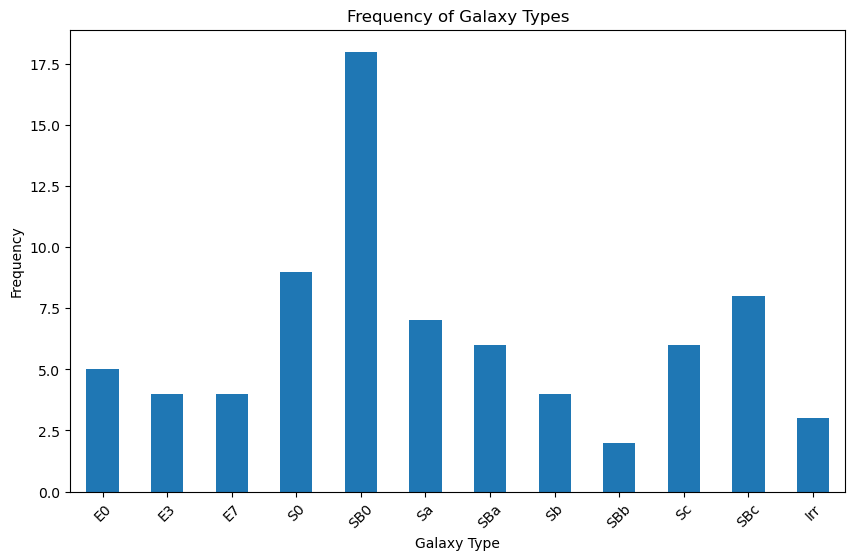

In [8]:
# Histogram

order = ['E0', 'E3', 'E7', 'S0', 'SB0', 'Sa', 'SBa', 'Sb', 'SBb', 'Sc', 'SBc', 'Irr']

type_counts = galaxies_class['Type'].value_counts().reindex(order, fill_value=0)

# Plot the histogram
plt.figure(figsize=(10, 6))
type_counts.plot(kind='bar')
plt.xlabel('Galaxy Type')
plt.ylabel('Frequency')
plt.title('Frequency of Galaxy Types')
plt.xticks(rotation=45)
plt.show()

In [9]:
galaxies_class.to_csv('./galaxy_classification_virgo.csv', index=False)

### Schechter Luminosity Function

The Schechter luminosity function is a useful tool to describe the distribution of galaxy luminosities in different environments, such as field galaxies, galaxy clusters, or groups. It is expressed as:

$$
\phi(L) = \phi^* \left( \frac{L}{L^*} \right)^{\alpha} e^{-\frac{L}{L^*}}
$$

Where:
- $ \phi(L) $ is the number density of galaxies with luminosity $ L $.
- $ \phi^* $ is a normalization factor representing the overall number density.
- $ L^* $ is the characteristic luminosity where the function transitions from a power-law to an exponential decline, indicating the "typical" luminosity of galaxies.
- $ \alpha $ is the slope of the power law, describing the distribution of low-luminosity galaxies (fainter than $ L^* $).

**Characteristics:**
- For $ L < L^* $, the function behaves as a power law with slope $ \alpha $, indicating an abundance of low-luminosity galaxies.
- For $ L > L^* $, the exponential term causes a rapid drop, indicating that bright, massive galaxies are rare.

#### Different Environments

1. **Field Galaxies:**
   - These galaxies are relatively isolated and not part of dense clusters or groups.
   - They exhibit a higher fraction of late-type (spiral) galaxies, suggesting that field environments favor the formation of star-forming, less massive galaxies.
   - This results in a flatter Schechter function, with a moderate slope dominated by spiral galaxies and a low fraction of early-type galaxies (e.g., ellipticals at 10%).

2. **Local Group:**
   - The Local Group includes galaxies like the Milky Way and Andromeda, along with a significant number of dwarf galaxies (e.g., dE, dSph at 69%).
   - It is dominated by low-luminosity, low-mass galaxies, consistent with a Schechter function having a steep slope.
   - The lack of high-luminosity galaxies and the dominance of dwarf types suggest that the Local Group's luminosity function is skewed toward faint galaxies.

3. **Virgo Cluster:**
   - The Virgo Cluster is a dense environment where the galaxy distribution differs from that of the field or Local Group.
   - This cluster shows a higher percentage of early-type galaxies, favoring the formation and survival of massive, bright galaxies.
   - The larger number of early-type galaxies results from processes like mergers and stripping, common in dense clusters.
   - Consequently, the Schechter function for the Virgo Cluster is flatter in its faint-end slope compared to that of the Local Group, emphasizing higher luminosity galaxies. 



In [10]:
# Calculate the frequency and percentage
frequency = galaxies_class['Type'].value_counts().sort_index()
percentage = (frequency / len(galaxies_class)) * 100

# Create a new dataframe with frequency and percentage
frequency_table = pd.DataFrame({
    'Frequency': frequency,
    'Percentage': percentage.astype(int)
})

# Display the table
print(frequency_table)


     Frequency  Percentage
E0           5           6
E3           4           5
E7           4           5
Irr          3           3
S0           9          11
SB0         18          23
SBa          6           7
SBb          2           2
SBc          8          10
Sa           7           9
Sb           4           5
Sc           6           7



### Ellipticities

The distribution of ellipticities of elliptical galaxies in the Universe is broad and varied because:
- Galaxies have different intrinsic shapes (oblate, prolate, triaxial).
- Their ellipticities are influenced by their formation and interaction histories.
- We observe these galaxies from random orientations.

In [11]:
# Virgo's Inner radius


object_ids = [8, 9, 10, 11, 13, 14, 15, 16, 17, 21, 25, 26, 27, 28, 30, 31, 32, 34, 35, 36, 37, 38, 72, 73]
inner_radius = galaxies_class[galaxies_class['Object'].isin(object_ids)]

outside_radius = galaxies_class[~galaxies_class['Object'].isin(object_ids)]

# Display the subsets
print("Inner Radius:")
print(inner_radius.head())
print("\nOutside Radius:")
print(outside_radius.head())


Inner Radius:
    Object Type    Source
7        8  SBa  NGC 4351
8        9   E0      M 84
9       10   Sc   IC 3311
10      11  SB0  NGC 4371
12      13   Sa  NGC 4388

Outside Radius:
   Object Type    Source
0       1  SB0  NGC 4267
1       2  SBc  NGC 4294
2       3   Sa  NGC 4313
3       4   Sc  NGC 4330
4       5   Sc  NGC 4316


In [12]:
import pandas as pd

# Assuming inner_radius and outside_radius are your DataFrames

def calculate_metrics(galaxies_class):
    # Count of each type in the DataFrame
    E_count = galaxies_class['Type'].isin(['E0', 'E3', 'E7']).sum()  # Count E
    S0_count = galaxies_class['Type'].isin(['S0', 'SB0']).sum()      # Count S0
    S_count = galaxies_class['Type'].isin(['Sa', 'Sb', 'Sc']).sum()   # Count S
    SB_count = galaxies_class['Type'].isin(['SBa', 'SBb', 'SBc']).sum()  # Count SB
    Irr_count = galaxies_class['Type'].isin(['Irr']).sum()            # Count Irr
    
    # Calculate (E + S0) / (S + SB + Irr)
    numerator = E_count + S0_count
    denominator = S_count + SB_count + Irr_count
    ratio1 = numerator / denominator if denominator > 0 else 0  # Handle division by zero
    
    # Calculate SB/S
    SB_over_S = SB_count / S_count if S_count > 0 else 0  # Handle division by zero

    return ratio1, SB_over_S

# Calculate metrics for both subsets
inner_radius_metrics = calculate_metrics(inner_radius)
outside_radius_metrics = calculate_metrics(outside_radius)

# Display the results
print("Inner Radius Metrics:")
print(f"(E + S0) / (S + SB + Irr): {inner_radius_metrics[0]}")
print(f"SB / S: {inner_radius_metrics[1]}")

print("\nOutside Radius Metrics:")
print(f"(E + S0) / (S + SB + Irr): {outside_radius_metrics[0]}")
print(f"SB / S: {outside_radius_metrics[1]}")


Inner Radius Metrics:
(E + S0) / (S + SB + Irr): 2.0
SB / S: 0.6

Outside Radius Metrics:
(E + S0) / (S + SB + Irr): 0.8571428571428571
SB / S: 1.0833333333333333


In [13]:
# Function to calculate frequency table without percentages
def frequency_table(galaxies_class):
    frequency = galaxies_class['Type'].value_counts().reset_index()
    frequency.columns = ['Type', 'Frequency']
    return frequency

# Create frequency tables for inner and outer radius
inner_radius_freq = frequency_table(inner_radius)
outside_radius_freq = frequency_table(outside_radius)

# Merge the two frequency tables
combined_freq = inner_radius_freq.set_index('Type').join(
    outside_radius_freq.set_index('Type'), 
    lsuffix='_Inner', 
    rsuffix='_Outside'
).fillna(0).reset_index()

# Rename columns for clarity
combined_freq.columns = ['Type', 'Frequency_Inner', 'Frequency_Outside']

# Display the combined frequency table
print("Combined Frequency Table:")
print(combined_freq)


Combined Frequency Table:
  Type  Frequency_Inner  Frequency_Outside
0  SB0                7                 11
1  SBa                3                  3
2   E0                3                  2
3   E3                3                  1
4   Sa                2                  5
5   Sb                2                  2
6   S0                2                  7
7   Sc                1                  5
8   E7                1                  3


### Calculating the Physical Size of the Inner Radius of the Virgo Cluster

To calculate the physical size of the inner radius of the Virgo cluster, we start with an angular size measured in arcseconds. The angular size given is **75 arcseconds**.

#### Convert Angular Size to Radians

The distance to the Virgo Cluster is **20 Megaparsecs (Mpc)**.

The relationship between angular size, physical size, and distance is expressed as:

$$
\text{Physical Size} = \text{Angular Size} \times \text{Distance}
$$

For small angles, this can be approximated as:

$$
\text{Physical Size} \approx \theta \times D
$$

Where:
- $ \theta $ is the angular size in radians.
- $ D $ is the distance to the object.


In [14]:
# Virgo cluster size
# arcmin
ir_size_as = 75
# radians
ir_size_rad = ir_size_as  / 60 * np.pi / 180
# distance
distance_virgo = 20 # Mpc

# Geometry calculations:
# tan(angular size) = physical size / distance 
# aproximation
# physical size = angular_size * distance
inner_radius_size = ir_size_rad * distance_virgo
print('Size of the inner radius of Virgo in Mpc')
print(inner_radius_size)

Size of the inner radius of Virgo in Mpc
0.4363323129985824


### High z galaxies & HDF 
Most expected galaxies are spiral, as we are looking back in time. It makes sense with the HDF.


<div style="text-align: center;">
    <img src="https://stsci-opo.org/STScI-01EVVQG2RXT2S71Z9PZ9F469Q0.jpg
    " width="500"/>
</div>


### Galaxy Zoo and the Sloan Digital Sky Survey (SDSS)

#### Galaxy Zoo

Galaxy Zoo is a citizen science project that allows volunteers to assist in the classification of galaxies from images taken by the Sloan Digital Sky Survey (SDSS). Launched in 2007, it aims to gather information about the morphology of galaxies, helping astronomers understand their formation and evolution. Participants can categorize galaxies based on their shapes, structures, and other features, contributing to significant scientific discoveries.

**Key Features:**
- **Crowdsourced Classification:** Volunteers can classify millions of galaxies quickly and efficiently.
- **Data for Research:** The classifications help researchers study the correlation between galaxy morphology and various astrophysical processes.
- **Community Engagement:** Galaxy Zoo encourages public interest in astronomy and engages citizens in scientific research.

<div style="text-align: center;">
    <img src="https://www.universetoday.com/wp-content/uploads/2008/04/gz-screenshot.jpg
    " height="300"/>
</div>

#### Sloan Digital Sky Survey (SDSS)

The Sloan Digital Sky Survey is a major astronomical survey that has mapped the universe in unprecedented detail since its launch in 2000. Using a dedicated 2.5-meter telescope at Apache Point Observatory in New Mexico, SDSS has collected imaging and spectroscopic data for millions of astronomical objects.

**ugriz Photometric System:**
The SDSS employs the ugriz system for photometry, which includes five filter bands:
- **u:** Ultraviolet
- **g:** Green
- **r:** Red
- **i:** Infrared
- **z:** Near-infrared

This system allows astronomers to gather data on the colors and brightness of celestial objects, facilitating the study of their physical properties and distributions.

<div style="text-align: center;">
    <img src="https://www.asahi-spectra.com/opticalfilters/img/fgr_ugrizband_large.jpg
    " height="300"/>
</div>



### 3. Quasars and Cosmology

### The 3C Catalogue and the Discovery of Quasars

#### Introduction to the 3C Catalogue

The 3C (Third Cambridge) Catalogue is a comprehensive catalog of radio sources compiled by the University of Cambridge. Initially published in the 1960s, it contains positions and flux densities of over 3,000 radio sources, primarily detected through radio telescopes. The 3C Catalogue has played a crucial role in the study of extragalactic objects, particularly quasars and other active galactic nuclei (AGN).

**Key Features of the 3C Catalogue:**
- **Extensive Data:** The catalogue includes data on position, flux density, and spectral index for each source.
- **Extragalactic Focus:** It specifically targets objects beyond our Milky Way galaxy, paving the way for research into the structure and evolution of the universe.
- **Legacy of Discoveries:** Many significant astronomical discoveries have stemmed from this catalogue, including the identification of quasars.



#### Quasar Discovery

Quasars, or quasi-stellar objects, are among the most luminous and distant objects in the universe. They were first identified in the early 1960s as a new class of astronomical objects, exhibiting extraordinary brightness and redshift, indicating that they were receding from Earth at high velocities. The discovery of quasars fundamentally changed our understanding of the universe and the nature of galaxies.

**Significance of Quasars:**
- **Distance and Brightness:** Quasars can outshine entire galaxies, making them detectable over vast distances. They are powered by supermassive black holes at the centers of galaxies, which consume surrounding material and emit enormous amounts of energy.
- **Cosmological Probes:** Quasars serve as important tools for studying the early universe and cosmic evolution due to their immense distances.
- **Link to Galaxy Formation:** Research suggests that quasars play a key role in the growth and evolution of galaxies, providing insights into the relationship between black holes and their host galaxies.

<div style="text-align: center;">
    <img src="https://media.springernature.com/lw1200/springer-static/image/art%3A10.1038%2F495165a/MediaObjects/41586_2013_Article_BF495165a_Figb_HTML.jpg
    " height="500"/>
</div>



### Plate Scale Calculation

- The plate scale is determined from the physical length of a segment of the spectrum. Here, the distance between the $ H_\gamma $ and $ H_\beta $ lines is given as 27 mm.
- The wavelength range between $ H_\delta $ (410 nm) and $ H_\gamma $ (486 nm) is 76 nm.
  
- The plate scale is then calculated as:

  $$
  \text{Plate Scale} = \frac{\text{Wavelength range (nm)}}{\text{Distance between lines (mm)}}
  $$


### Rest Wavelengths of the Balmer Series

- The rest wavelengths for the Balmer lines are:
  - $ H_\delta = 410 $ nm,
  - $ H_\gamma = 434 $ nm,
  - $ H_\beta = 486 $ nm.

### Redshift Calculation

- The observed wavelength ($ \lambda_{\text{observed}} $) is calculated as:

  $$
  \lambda_{\text{observed}} = \lambda_{\text{rest}} + \text{distance} \cdot \text{plate scale}
  $$

- The redshift $ z $ is then calculated using:

  $$
  z = \frac{\lambda_{\text{observed}} - \lambda_{\text{rest}}}{\lambda_{\text{rest}}}
  $$


### Doppler Velocity Calculation

- The Doppler velocity ($ v $) can be calculated using:

  $$
  v = z \cdot c
  $$

  where $ c $ is the speed of light.




In [15]:
# plate scale of the spectrum
# From H_beta to H_delta
length_mm = 27
length_nm = 486 - 410 
ps_spec = length_nm / length_mm

# Difference in position of the Balmer lines
Hd_mm = 23
Hg_mm = 24
Hb_mm = 26

# Rest wavelength of the Balmer series

Hd_wl = 410 #nm
Hg_wl = 434 #nm
Hb_wl = 486 #nm


# Redshift calculation

def redshift_ps(plate_scale, dif_pos, lambda_rest):
    lambda_obs = lambda_rest+dif_pos*plate_scale
    z = lambda_obs/lambda_rest - 1
    return z


z_Hd = redshift_ps(ps_spec, Hd_mm, Hd_wl)
z_Hg = redshift_ps(ps_spec, Hg_mm, Hg_wl)
z_Hb = redshift_ps(ps_spec, Hb_mm, Hb_wl)
redshift_qso = np.mean([z_Hb, z_Hd, z_Hg])


print('Redshift calculation')
print('H_delta, H_gamma, H_beta: ', z_Hd, z_Hg, z_Hb)
print('Mean redshift: ', redshift_qso)


def doppler_velocity(z):
    c = ct.c / 1e3
    return c*z # km / s


doppler_hd = doppler_velocity(z_Hd)
doppler_hg = doppler_velocity(z_Hg)
doppler_hb = doppler_velocity(z_Hb)

print(' ')
print('Doppler velocities')
print('H_delta, H_gamma, H_beta: ', int(doppler_hd), int(doppler_hg), int(doppler_hb))


Redshift calculation
H_delta, H_gamma, H_beta:  0.15790424570912376 0.15565796210957505 0.15058680079256215
Mean redshift:  0.15471633620375366
 
Doppler velocities
H_delta, H_gamma, H_beta:  47338 46665 45144


### Hubble Law

The Hubble Law describes the relationship between the distance to a galaxy and its redshift. It is fundamental to our understanding of the expansion of the universe. The law can be expressed as:

$$
v = H_0 \cdot d
$$

where:
- $ v $ is the recessional velocity of the galaxy,
- $ H_0 $ is the Hubble constant (typically measured in km/s/Mpc),
- $ d $ is the distance to the galaxy (in megaparsecs, Mpc).

### Redshift and Distance Calculation

For a given galaxy, the redshift $ z $ can be related to its recessional velocity using the formula:

$$
v = z \cdot c
$$

where:
- $ c $ is the speed of light (approximately $ 3 \times 10^5 $ km/s).

Substituting this into the Hubble Law gives:

$$
z \cdot c = H_0 \cdot d
$$

From this, we can rearrange to calculate the distance $ d $:

$$
d = \frac{z \cdot c}{H_0}
$$


In [16]:
# Hubble's Law
# v = H0 * d

H0 = 70 # km / s / Mpc
v = ct.c / (1e3) *  redshift_qso
distance_3C273 = v/H0


print('Velocity: ', v, 'Km')
print('Distance: ', distance_3C273, 'Mpc')

Velocity:  46382.7907232777 Km
Distance:  662.6112960468242 Mpc



### Plate Scale Calculation Using Stellar Coordinates

To calculate the distance between two stars given their equatorial coordinates (Right Ascension and Declination), we can follow these steps:

#### 1. Convert Right Ascension (RA) and Declination (Dec) to Radians
- Right Ascension (RA) is expressed in hours, minutes, and seconds. First, convert it to decimal degrees and then to radians.
- Declination (Dec) is given in degrees, minutes, and seconds and should also be converted to radians.

#### 2. Calculate Angular Distance
- To find the angular separation between two points on the celestial sphere, use the following formula:
$$
\cos(d) = \sin(\delta_1) \sin(\delta_2) + \cos(\delta_1) \cos(\delta_2) \cos(\alpha_1 - \alpha_2)
$$
- In this formula, $\delta_1$ and $\delta_2$ are the declinations of the two stars, while $\alpha_1$ and $\alpha_2$ are their right ascensions.



#### 3. Plate Scale Calculation

The plate scale is calculated using the formula:
$$
\text{Plate Scale} = \frac{d_{\text{arcsec}}}{\text{size}_{\text{mm}}}
$$
Where:
- $d_{\text{arcsec}}$ is the angular distance between the two stars in arcseconds,
- $\text{size}_{\text{mm}}$ is the measured distance in millimeters.



![alt text](image.png)


In [17]:
def plate_scale_stars(pos_1, pos_2, size_mm):
    # Function to convert from hours, minutes, seconds to degrees
    def ra_to_radians(hours, minutes, seconds):
        return np.radians((hours + minutes/60 + seconds/3600) * 15)

    # Function to convert from degrees, minutes, seconds to degrees
    def dec_to_radians(degrees, minutes, seconds):
        return np.radians(degrees + minutes/60 + seconds/3600)
    
    ra_1, dec_1 = ra_to_radians(*pos_1[0]), dec_to_radians(*pos_1[1])
    ra_2, dec_2 = ra_to_radians(*pos_2[0]), dec_to_radians(*pos_2[1])

    cos_d = (np.sin(dec_1) * np.sin(dec_2) +
          np.cos(dec_1) * np.cos(dec_2) *
          np.cos(ra_1 - ra_2))
    
    # Distance in degrees
    d_deg = np.rad2deg(np.arccos(cos_d))

    # Distance in arcsec
    d_arcsec = d_deg * 60 * 60

    # print(d_arcsec)

    plate_scale = d_arcsec / size_mm

    return plate_scale


star_G = ([[12, 26, 29.77], [2, 19, 53.3]])
star_X = ([[12, 26, 34.41], [2, 20, 10.5]]) #', unit=(u.hourangle, u.deg))
star_B = ([[12, 26, 29.40], [2, 18, 51.1]]) #', unit=(u.hourangle, u.deg))

GX_mm = 43
GB_mm = 38
XB_mm = 66

ps_GX = plate_scale_stars(star_G, star_X, GX_mm)
ps_GB = plate_scale_stars(star_G, star_B, GB_mm)
ps_XB = plate_scale_stars(star_X, star_B, XB_mm)
ps_qso = np.mean([ps_GX, ps_GB, ps_XB])

print('Plate scale:')
print('GX, GB, XB: ', ps_GX, ps_GB, ps_XB)
print('Mean: ', ps_qso)

Plate scale:
GX, GB, XB:  1.665994132163598 1.6433345398056765 1.6557900104579595
Mean:  1.655039560809078


In [18]:
# Size of the Jet from the center of the galaxy (M 87)

jet_mm = 12

jet_as = jet_mm * ps_qso

print(jet_as)
# Size of the jet:

size_jet = distance_3C273 * np.radians(jet_as / 60 / 60) * 1e3

print('Jet size in Kpc:')
print(size_jet)


# galaxy size 

galaxy_mm = 6
galaxy_as = galaxy_mm * ps_qso

size_galaxy = distance_3C273 * np.radians(galaxy_as / 60 / 60) * 1e3

print('Size of the (visible) underlying galaxy in Kpc:')
print(size_galaxy)


19.860474729708937
Jet size in Kpc:
63.80038912209191
Size of the (visible) underlying galaxy in Kpc:
31.900194561045954


### Proper Distance and Angular Distance


#### Case 1: Hubble's Law is Valid

The proper distance can be calculated using the relationship:
$$
d_{P_{z}} = \frac{v_z}{H_0}
$$
where $v_z = c \cdot z$, with $c$ being the speed of light and $H_0$ the Hubble constant.


#### Case 2: Hubble's Law is Not Valid

When Hubble's Law is not valid, the proper distance is computed using:
$$
d_P = \int_0^{z} \frac{c}{H(z)} \, dz
$$
where the Hubble parameter $H(z)$ is defined as:
$$
H(z) = H_0 \sqrt{\Omega_{matter} (1 + z)^3 + \Omega_{\Lambda}}
$$

**Calculate the Angular Distance ($d_A$)**:
   The angular distance remains the same:
   $$
   d_A = \frac{d_P}{1 + z}
   $$



In [25]:
# Galaxy at z = 2

# If the Hubble Law is valid for this redshitf 
z_2 = 2
v_z2 = ct.c * z_2 * (1e-3) # km/s
dP_z2 = v_z2 / H0 # Proper distance in Mpc

# Considering the standard LCDM model
dA = dP_z2 / (1+z_2) # Angular distance in Mpc

z2_galaxy = 30 * (1e-3)  # Size of the galaxy in Mpc

# Angle in arcsec
z2_arcsec = (z2_galaxy / dA) * (180 / np.pi ) * 60 * 60

print('Valid Hubble Law:')
print('Proper distance (Mpc): ', dP_z2)
print('Angular distance (Mpc): ', dA)
print('Angular size (arcsec): ', z2_arcsec)



# If the Hubble's Law is not valid at z=2
H0 = 70#.value
Omega_lambda = 0.7#.value
Omega_matter = 0.3#.value

def proper_distance(z):
    def H(z):
        # Hubble parameter
        return H0 * np.sqrt(Omega_matter * (1 + z)**3 + Omega_lambda)
    
    def integrand(z):
        return ct.c*(1e-3) / H(z)
    
    return quad(integrand, 0, z)[0]

# Proper distance
dP_ = proper_distance(z_2)
# Angular distance
dA_ = dP_ / (1+z_2)
# Angular size in arcsec 
ang_ = (z2_galaxy / dA_) * 180 / np.pi * 60 * 60

print(' ')
print('Not valid Hubble Law at z=2:')
print('Proper distance (Mpc): ', dP_)
print('Angular distance (Mpc): ', dA_)
print('Angular size (arcsec): ', ang_)

    

Valid Hubble Law:
Proper distance (Mpc):  8565.4988
Angular distance (Mpc):  2855.1662666666666
Angular size (arcsec):  2.1672798042115975
 
Not valid Hubble Law at z=2:
Proper distance (Mpc):  5179.862074409372
Angular distance (Mpc):  1726.6206914697907
Angular size (arcsec):  3.5838468854125605


### Magnitudes

The apparent magnitude ($m$) of an astronomical object can be calculated from its absolute magnitude ($M$) and its distance ($d$) in parsecs using the following formula:

$$
m = M + 5 \log_{10}(d) - 5
$$



In [20]:
# Apparent magnitude of the galaxy
# m - M = 5*log(d/10)
# Let's asume that the Hubble Law does not hold

# Luminosity distance:
# D_L = dP_ * (1+z_2) * (1e6) # pc
D_L = dP_z2 * (1+z_2)**2 * (1e6) # pc, valid Hubble Law

# Absolute magnitude of the milky way
M_MW = -24

# apparent magnitude
m_z2 = M_MW + 5*np.log10(D_L / 10)
print('Apparent magnitude: ', m_z2)


Apparent magnitude:  25.43497584008489


In [21]:
## Absolute magnitude of 3C 273

m_3C273 = 12.9 

# Absolute magnitude
M_3C273 = m_3C273 - 5*np.log10(distance_3C273 * (1e6) / 10)

print('Absolute magnitude 3C 273: ', M_3C273)

Absolute magnitude 3C 273:  -26.206294176813515


### Estimating the Upper Limit of the Accretion Disk Size from a Quasar Light Curve

To estimate the upper limit of the accretion disk size based on the maximum brightness change observed in a quasar’s light curve, we can use the time interval of this change and the speed of light. 

The time interval $\Delta t$ (in days) represents the time over which the minimum and maximum brightness levels are observed. If the change in brightness occurs over a time period $\Delta t$, the size of the emitting region responsible for this change can be approximated by considering the speed of light $c$. The upper limit for the accretion disk size, $R_{\text{disk}}$, is given by:

$$
R_{\text{disk}} \leq c \cdot \Delta t .
$$

If the disk were larger than this value, the variability would take longer due to the light travel time across the disk. It assumes that the light travel time across the emitting region is the primary driver of the observed variability.



In [22]:
# AGN variability 

delta_t_days = 2000 # Time between minimum and maximum activity
delta_t_seconds = delta_t_days * 24 * 60 * 60

size_BLR_km = delta_t_seconds * ct.c * (1e-3) *u.km

size_BLR_pc = size_BLR_km.to(u.pc)

print('Size of the AD <', size_BLR_pc)

Size of the AD < 1.678857734623138 pc



### Comparison of the Continuum Energy Distribution of 3C 273 with the Milky Way and IR-Galaxy Spectra


1. **Broadband Spectrum of 3C 273**:
   - 3C 273, as a quasar, exhibits a broad and continuous energy distribution spanning from the radio up to the X-ray regions. 
   - Unlike the Milky Way, which has a spectrum dominated by stars (mainly optical and infrared regions), 3C 273 shows strong emission across the electromagnetic spectrum, indicating the presence of non-thermal processes and intense activity in its active galactic nucleus (AGN).
   - The IR-galaxy spectra, on the other hand, typically show a peak in the infrared region due to dust and star-forming activity. In contrast, 3C 273 shows a much broader energy distribution that extends beyond the infrared into higher energy wavelengths.

2. **UV Bump in Quasars**:
   - The **UV bump** refers to the prominent rise in emission in the ultraviolet (UV) region observed in many quasar spectra, including 3C 273. This feature is not present in the Milky Way or IR-galaxy spectra.
   - The UV bump is associated with thermal emission from the **accretion disk** around the supermassive black hole in the quasar. As gas falls into the black hole, it heats up and emits a continuum of radiation, with a peak typically in the UV range.
   - The UV bump distinguishes quasars like 3C 273 from other galaxies, as it indicates the presence of a highly energetic central engine (AGN) fueled by accretion processes.



<div style="text-align: center;">
    <img src="https://www.researchgate.net/publication/284730689/figure/fig1/AS:644281920389123@1530620188902/A-schematic-representation-of-an-AGNs-Spectral-Energy-Distribution-SED-loosely.png
    " height="400"/>
</div>



### What is VLBI (Very Long Baseline Interferometry)?

**Very Long Baseline Interferometry (VLBI)** is a technique used in radio astronomy to achieve high-resolution observations of astronomical objects, such as quasars, black holes, and distant galaxies. It works by combining the signals received by multiple radio telescopes spread across vast distances, creating a single, "virtual" telescope with a size equivalent to the maximum separation (baseline) between them.

### How Does VLBI Work?

1. **Network of Telescopes**:
   - VLBI involves an array of radio telescopes located in different geographical locations around the world. Each telescope observes the same astronomical object at the same time.
   - By placing telescopes far apart, sometimes even on different continents, the effective diameter of the "virtual" telescope becomes incredibly large—up to thousands of kilometers.

2. **Signal Correlation**:
   - The signals collected by each telescope are recorded with extremely precise time stamps using atomic clocks. These time stamps ensure that the data from each telescope can be synchronized later.
   - The recorded signals are then sent to a central processing unit where they are **correlated**, combining them into a single, high-resolution observation.

3. **Achieving High Resolution**:
   - The resolution of VLBI observations depends on the distance between the telescopes (the baseline). The larger the baseline, the finer the resolution. VLBI can achieve angular resolutions on the order of **milliarcseconds**, which is much finer than what is possible with optical telescopes.

### Applications of VLBI

- **Mapping Black Holes and Quasars**:
  - VLBI is crucial for observing the detailed structure of supermassive black holes and their surrounding regions (e.g., the Event Horizon Telescope used VLBI to image the shadow of the black hole in M87).
  - It is also used to study the jets emitted by quasars, providing insight into the processes near the event horizon of black holes.

- **Measuring Earth’s Rotation and Tectonic Movements**:
  - VLBI is used in geodesy (Earth measurement) to determine the precise rotation of the Earth, the movement of tectonic plates, and other geophysical processes.



### Superluminal Expansion in Relativistic Jets

**Superluminal expansion** refers to the phenomenon observed in some **relativistic jets** emitted by active galactic nuclei (AGNs), quasars, or black holes, where the apparent speed of the jet exceeds the speed of light ($c$). This does not violate the laws of physics; instead, it is a result of the geometry and relativistic effects.


**Relativistic Jets**:
   - Jets emitted by quasars or black holes travel at speeds very close to the speed of light (relativistic speeds).
   - When such jets are directed nearly along the line of sight to Earth, their motion creates an optical illusion of exceeding the speed of light.

**Geometric Explanation**:
   - If the jet is moving at an angle $\theta$ relative to the observer’s line of sight and at a speed $v$ close to $c$, the time it takes for light from different points of the jet to reach the observer is affected.
   - The apparent transverse speed ($v_{\text{app}}$) can be much greater than the actual speed due to the relativistic effects and the angle of the jet.

**Apparent Velocity Formula**:
   - The apparent velocity $v_{\text{app}}$ can be expressed as:
     $$
     v_{\text{app}} = \frac{v \sin(\theta)}{1 - \frac{v \cos(\theta)}{c}}
     $$
   - When $v$ is close to $c$ and $\theta$ is small, $v_{\text{app}}$ can appear greater than $c$. This is a visual effect, not a physical violation of relativity.


<!-- 

<div style="text-align: center;">
    <img src="cid:superluminal_plot" alt="Superluminal Expansion Plot" height="500"/>
</div> -->



In [23]:
# VLBI 

# Calculating the velocity in mas/year
plate_scale_vlbi = 2 / 12 # mas/mm (From the paper 2 mas for every tick in the plot)

# Size of the blobs in mas

# blob_1 = 50 * plate_scale_vlbi
# blob_2 = 62 * plate_scale_vlbi
# blob_3 = 79 * plate_scale_vlbi

blob_1 = 17 * plate_scale_vlbi
blob_2 = 21 * plate_scale_vlbi
blob_3 = 32 * plate_scale_vlbi
# Years
y1 = 1984.12
y2 = 1984.93
y3 = 1985.60


# Velocity 

def velocity_blobs(sa, sb, t1, t2):
    return (sb - sa) / (t2 -t1)


# Links
v_12 = velocity_blobs(blob_1, blob_2, y1, y2)
v_23 = velocity_blobs(blob_2, blob_3, y2, y3)
v_13 = velocity_blobs(blob_1, blob_3, y1, y3)

# v_jet = np.mean([v_12, v_23, v_13]) # mas / year

v_jet = 0.76 # Value from the image

v_jet_sec_rad = v_jet * (1e-3) / 60 / 60 / 180 / (1e7)
# 1 year approx pi X 10^7 sec :) 


print('Angular velocity (mas/year):')
print(v_12, v_23, v_13)

Angular velocity (mas/year):
0.8230452674895367 2.73631840796083 1.6891891891891684


In [24]:
# Transversal velocity 
v_transversal = v_jet_sec_rad * distance_3C273 * (3.085e22) / (1+redshift_qso)
v_transversal / ct.c

6.925586807571506